#### Author's Information:
        Author : Ali Rizvi.
        Stu ID : 2410057
        Module : HEP502 of MSc Computer Sciences with Artificial Intelligence.
        Title  : Comparative Evaluation of MLP and CNN on Fashion-MNIST.
        Purpose: Final Assessment
---


| #| ## of Notebook | Title of Notebook |
|--|---|---|
| 1| 00 | Data Loading and Sanity Checks |
| 2| 01 | Baseline MLP |
| 3| 02 | Baseline CNN |
| 4| 03 | Regularisation Experiments |
| 5| 04 | Depth and Capacity Variance |
| 6| 05 | Robustness Testing |
| **7th**| **06** | **Consolidated Analysis** |

**This is Notebook 06,** 7th (final) of this 7-notebook series. The following are the goals of this notebook:
## Goals:
- Load all the JSON logs, and build final comparison summaries
- Plot Accuracy vs number of Parameters, Accuracy vs training time taken, Generalization Gap vs Depth, and Efficiency curvevs.

**This notebook prodcues final figures for the report, clean summary tables, and efficiency plots**

#### Importing libraries

In [127]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [128]:
OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
MODEL_DIR = OUTPUT_DIR / "models"

directories = [OUTPUT_DIR, FIG_DIR, LOG_DIR, MODEL_DIR]
for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

### Loading Metric Logs

#### Load JSON experiment logs

In [129]:
def load_all_logs(log_dir: Path) -> pd.DataFrame:
    records = []
    # Scan for all saved metric files from previous runs
    for path in sorted(log_dir.glob("*_metrics.json")):
        with open(path, "r") as f:
            rec = json.load(f)
        rec["_log_file"] = path.name  # Keep source filename for traceability
        records.append(rec)
    
    return pd.DataFrame(records)  # Consolidate into a single table for analysis

df_raw = load_all_logs(LOG_DIR)
df_raw.head()

,model_name,seed,epochs,batch_size,optimizer,learning_rate,train_time_sec,num_params,test_loss,test_accuracy,acc_per_10k_params,final_train_accuracy,final_val_accuracy,_log_file,run_name,arch,dropout_rate,l2_strength,generalisation_gap
0,baseline_cnn,42.0,20,128,Adam,0.001,720.386743,421642,0.404130,0.9138,0.021672,0.985000,0.914750,baseline_cnn_metrics.json,NaN,NaN,NaN,NaN,NaN
1,baseline_mlp,42.0,20,128,Adam,0.001,96.620260,101770,0.378516,0.8750,0.085978,0.929250,0.883583,baseline_mlp_metrics.json,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,20,128,NaN,0.001,720.857799,421642,0.393044,0.9159,0.021722,0.985875,0.919833,cnn_baseline_metrics.json,cnn_baseline,cnn,0.0,0.0000,0.066042
3,NaN,NaN,20,128,NaN,0.001,567.100399,421642,0.346876,0.9165,0.021736,0.954958,0.918000,cnn_drop0.3_l20.0001_metrics.json,cnn_drop0.3_l20.0001,cnn,0.3,0.0001,0.036958
4,NaN,NaN,20,128,NaN,0.001,704.503709,421642,0.280051,0.9178,0.021767,0.966771,0.922417,cnn_drop0.3_metrics.json,cnn_drop0.3,cnn,0.3,0.0000,0.044354


In [130]:
print(f"Total runs loaded: {len(df_raw)}")

Total runs loaded: 10


#### The data is not stored in a proper format. Lets do some preprocessing.


In [131]:
df = df_raw.copy()

# Unify run identifier
if "run_name" not in df.columns:
    df["run_name"] = np.nan
if "model_name" in df.columns:
    df["run_name"] = df["run_name"].fillna(df["model_name"])
df.head()

,model_name,seed,epochs,batch_size,optimizer,learning_rate,train_time_sec,num_params,test_loss,test_accuracy,acc_per_10k_params,final_train_accuracy,final_val_accuracy,_log_file,run_name,arch,dropout_rate,l2_strength,generalisation_gap
0,baseline_cnn,42.0,20,128,Adam,0.001,720.386743,421642,0.404130,0.9138,0.021672,0.985000,0.914750,baseline_cnn_metrics.json,baseline_cnn,NaN,NaN,NaN,NaN
1,baseline_mlp,42.0,20,128,Adam,0.001,96.620260,101770,0.378516,0.8750,0.085978,0.929250,0.883583,baseline_mlp_metrics.json,baseline_mlp,NaN,NaN,NaN,NaN
2,NaN,NaN,20,128,NaN,0.001,720.857799,421642,0.393044,0.9159,0.021722,0.985875,0.919833,cnn_baseline_metrics.json,cnn_baseline,cnn,0.0,0.0000,0.066042
3,NaN,NaN,20,128,NaN,0.001,567.100399,421642,0.346876,0.9165,0.021736,0.954958,0.918000,cnn_drop0.3_l20.0001_metrics.json,cnn_drop0.3_l20.0001,cnn,0.3,0.0001,0.036958
4,NaN,NaN,20,128,NaN,0.001,704.503709,421642,0.280051,0.9178,0.021767,0.966771,0.922417,cnn_drop0.3_metrics.json,cnn_drop0.3,cnn,0.3,0.0000,0.044354


In [132]:
# Ensure required columns exist
required = [
    "arch", "test_accuracy", "num_params", "train_time_sec",
    "final_train_accuracy", "final_val_accuracy",
    "dropout_rate", "l2_strength"
]
for c in required:
    if c not in df.columns:
        df[c] = np.nan

In [133]:
# Infer arch if missing (robust rules)
mask = df["arch"].isna()

In [134]:
# Infer from run_name
df.loc[mask & df["run_name"].str.contains("cnn", na=False), "arch"] = "cnn"
df.loc[mask & df["run_name"].str.contains("mlp", na=False), "arch"] = "mlp"

# Infer from log file name (backup)
mask = df["arch"].isna()
df.loc[mask & df["_log_file"].str.contains("cnn", na=False), "arch"] = "cnn"
df.loc[mask & df["_log_file"].str.contains("mlp", na=False), "arch"] = "mlp"

df.head()

,model_name,seed,epochs,batch_size,optimizer,learning_rate,train_time_sec,num_params,test_loss,test_accuracy,acc_per_10k_params,final_train_accuracy,final_val_accuracy,_log_file,run_name,arch,dropout_rate,l2_strength,generalisation_gap
0,baseline_cnn,42.0,20,128,Adam,0.001,720.386743,421642,0.404130,0.9138,0.021672,0.985000,0.914750,baseline_cnn_metrics.json,baseline_cnn,cnn,NaN,NaN,NaN
1,baseline_mlp,42.0,20,128,Adam,0.001,96.620260,101770,0.378516,0.8750,0.085978,0.929250,0.883583,baseline_mlp_metrics.json,baseline_mlp,mlp,NaN,NaN,NaN
2,NaN,NaN,20,128,NaN,0.001,720.857799,421642,0.393044,0.9159,0.021722,0.985875,0.919833,cnn_baseline_metrics.json,cnn_baseline,cnn,0.0,0.0000,0.066042
3,NaN,NaN,20,128,NaN,0.001,567.100399,421642,0.346876,0.9165,0.021736,0.954958,0.918000,cnn_drop0.3_l20.0001_metrics.json,cnn_drop0.3_l20.0001,cnn,0.3,0.0001,0.036958
4,NaN,NaN,20,128,NaN,0.001,704.503709,421642,0.280051,0.9178,0.021767,0.966771,0.922417,cnn_drop0.3_metrics.json,cnn_drop0.3,cnn,0.3,0.0000,0.044354


In [135]:
# Fill dropout/l2 missing with 0
df["dropout_rate"] = df["dropout_rate"].fillna(0.0)
df["l2_strength"] = df["l2_strength"].fillna(0.0)

df.head()

,model_name,seed,epochs,batch_size,optimizer,learning_rate,train_time_sec,num_params,test_loss,test_accuracy,acc_per_10k_params,final_train_accuracy,final_val_accuracy,_log_file,run_name,arch,dropout_rate,l2_strength,generalisation_gap
0,baseline_cnn,42.0,20,128,Adam,0.001,720.386743,421642,0.404130,0.9138,0.021672,0.985000,0.914750,baseline_cnn_metrics.json,baseline_cnn,cnn,0.0,0.0000,NaN
1,baseline_mlp,42.0,20,128,Adam,0.001,96.620260,101770,0.378516,0.8750,0.085978,0.929250,0.883583,baseline_mlp_metrics.json,baseline_mlp,mlp,0.0,0.0000,NaN
2,NaN,NaN,20,128,NaN,0.001,720.857799,421642,0.393044,0.9159,0.021722,0.985875,0.919833,cnn_baseline_metrics.json,cnn_baseline,cnn,0.0,0.0000,0.066042
3,NaN,NaN,20,128,NaN,0.001,567.100399,421642,0.346876,0.9165,0.021736,0.954958,0.918000,cnn_drop0.3_l20.0001_metrics.json,cnn_drop0.3_l20.0001,cnn,0.3,0.0001,0.036958
4,NaN,NaN,20,128,NaN,0.001,704.503709,421642,0.280051,0.9178,0.021767,0.966771,0.922417,cnn_drop0.3_metrics.json,cnn_drop0.3,cnn,0.3,0.0000,0.044354


In [136]:
# Recompute generalisation gap where possible
df["generalisation_gap"] = np.nan
have_gap = df["final_train_accuracy"].notna() & df["final_val_accuracy"].notna()
df.loc[have_gap, "generalisation_gap"] = df.loc[have_gap, "final_train_accuracy"] - df.loc[have_gap, "final_val_accuracy"]

df.head()

,model_name,seed,epochs,batch_size,optimizer,learning_rate,train_time_sec,num_params,test_loss,test_accuracy,acc_per_10k_params,final_train_accuracy,final_val_accuracy,_log_file,run_name,arch,dropout_rate,l2_strength,generalisation_gap
0,baseline_cnn,42.0,20,128,Adam,0.001,720.386743,421642,0.404130,0.9138,0.021672,0.985000,0.914750,baseline_cnn_metrics.json,baseline_cnn,cnn,0.0,0.0000,0.070250
1,baseline_mlp,42.0,20,128,Adam,0.001,96.620260,101770,0.378516,0.8750,0.085978,0.929250,0.883583,baseline_mlp_metrics.json,baseline_mlp,mlp,0.0,0.0000,0.045667
2,NaN,NaN,20,128,NaN,0.001,720.857799,421642,0.393044,0.9159,0.021722,0.985875,0.919833,cnn_baseline_metrics.json,cnn_baseline,cnn,0.0,0.0000,0.066042
3,NaN,NaN,20,128,NaN,0.001,567.100399,421642,0.346876,0.9165,0.021736,0.954958,0.918000,cnn_drop0.3_l20.0001_metrics.json,cnn_drop0.3_l20.0001,cnn,0.3,0.0001,0.036958
4,NaN,NaN,20,128,NaN,0.001,704.503709,421642,0.280051,0.9178,0.021767,0.966771,0.922417,cnn_drop0.3_metrics.json,cnn_drop0.3,cnn,0.3,0.0000,0.044354


In [137]:
# Keep only rows that have the essentials
df = df[df["run_name"].notna()]
df = df[df["test_accuracy"].notna()]
df = df[df["num_params"].notna()]
df = df[df["train_time_sec"].notna()]

df[["run_name", "arch", "test_accuracy",  "num_params", "train_time_sec", "generalisation_gap", "dropout_rate", "l2_strength", "_log_file"]].head(10)

,run_name,arch,test_accuracy,num_params,train_time_sec,generalisation_gap,dropout_rate,l2_strength,_log_file
0,baseline_cnn,cnn,0.9138,421642,720.386743,0.070250,0.0,0.0000,baseline_cnn_metrics.json
1,baseline_mlp,mlp,0.8750,101770,96.620260,0.045667,0.0,0.0000,baseline_mlp_metrics.json
2,cnn_baseline,cnn,0.9159,421642,720.857799,0.066042,0.0,0.0000,cnn_baseline_metrics.json
3,cnn_drop0.3_l20.0001,cnn,0.9165,421642,567.100399,0.036958,0.3,0.0001,cnn_drop0.3_l20.0001_metrics.json
4,cnn_drop0.3,cnn,0.9178,421642,704.503709,0.044354,0.3,0.0000,cnn_drop0.3_metrics.json
5,cnn_l20.0001,cnn,0.9045,421642,719.061683,0.063750,0.0,0.0001,cnn_l20.0001_metrics.json
6,mlp_baseline,mlp,0.8677,101770,96.165987,0.050792,0.0,0.0000,mlp_baseline_metrics.json
7,mlp_drop0.3_l20.0001,mlp,0.8785,101770,86.051179,0.008167,0.3,0.0001,mlp_drop0.3_l20.0001_metrics.json
8,mlp_drop0.3,mlp,0.8820,101770,93.697027,0.012375,0.3,0.0000,mlp_drop0.3_metrics.json
9,mlp_l20.0001,mlp,0.8657,101770,95.913012,0.042292,0.0,0.0001,mlp_l20.0001_metrics.json


In [138]:
# Remove the duplicates
df = df.sort_values("test_accuracy", ascending=False)
df = df.drop_duplicates(subset=["run_name"], keep="first").reset_index(drop=True)

print(f"After duplicates removal: {len(df)}")

After duplicates removal: 10


In [139]:
# Form clean_df
clean_df = df[[
    "run_name", "arch", "test_accuracy", "num_params", "train_time_sec",
    "generalisation_gap", "dropout_rate", "l2_strength"
]].copy()

clean_df = clean_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)
clean_df

,run_name,arch,test_accuracy,num_params,train_time_sec,generalisation_gap,dropout_rate,l2_strength
0,cnn_drop0.3,cnn,0.9178,421642,704.503709,0.044354,0.3,0.0000
1,cnn_drop0.3_l20.0001,cnn,0.9165,421642,567.100399,0.036958,0.3,0.0001
2,cnn_baseline,cnn,0.9159,421642,720.857799,0.066042,0.0,0.0000
3,baseline_cnn,cnn,0.9138,421642,720.386743,0.070250,0.0,0.0000
4,cnn_l20.0001,cnn,0.9045,421642,719.061683,0.063750,0.0,0.0001
5,mlp_drop0.3,mlp,0.8820,101770,93.697027,0.012375,0.3,0.0000
6,mlp_drop0.3_l20.0001,mlp,0.8785,101770,86.051179,0.008167,0.3,0.0001
7,baseline_mlp,mlp,0.8750,101770,96.620260,0.045667,0.0,0.0000
8,mlp_baseline,mlp,0.8677,101770,96.165987,0.050792,0.0,0.0000
9,mlp_l20.0001,mlp,0.8657,101770,95.913012,0.042292,0.0,0.0001


In [140]:
# Save it
clean_df.to_csv(TABLE_DIR / "all_runs_clean.csv", index=False)
print("Saved:", TABLE_DIR / "all_runs_clean.csv")

Saved: outputs\tables\all_runs_clean.csv


### Core Summary Outputs

In [141]:
best_per_arch = (clean_df.sort_values("test_accuracy", ascending=False)
                 .groupby("arch", as_index=False)
                 .head(1))

best_per_arch

,run_name,arch,test_accuracy,num_params,train_time_sec,generalisation_gap,dropout_rate,l2_strength
0,cnn_drop0.3,cnn,0.9178,421642,704.503709,0.044354,0.3,0.0
5,mlp_drop0.3,mlp,0.8820,101770,93.697027,0.012375,0.3,0.0


In [142]:
best_per_arch.to_csv(TABLE_DIR / "best_per_arch.csv", index=False)

#### Parameter Efficiency (per 10K oarams)

In [143]:
clean_df["acc_per_10k_params"] = clean_df["test_accuracy"] / (clean_df["num_params"] / 10000.0)
eff_df = clean_df.sort_values("acc_per_10k_params", ascending=False).reset_index(drop=True)

eff_df[["run_name","arch","test_accuracy","num_params","acc_per_10k_params"]].head(10)

,run_name,arch,test_accuracy,num_params,acc_per_10k_params
0,mlp_drop0.3,mlp,0.8820,101770,0.086666
1,mlp_drop0.3_l20.0001,mlp,0.8785,101770,0.086322
2,baseline_mlp,mlp,0.8750,101770,0.085978
3,mlp_baseline,mlp,0.8677,101770,0.085261
4,mlp_l20.0001,mlp,0.8657,101770,0.085064
5,cnn_drop0.3,cnn,0.9178,421642,0.021767
6,cnn_drop0.3_l20.0001,cnn,0.9165,421642,0.021736
7,cnn_baseline,cnn,0.9159,421642,0.021722
8,baseline_cnn,cnn,0.9138,421642,0.021672
9,cnn_l20.0001,cnn,0.9045,421642,0.021452


In [144]:
eff_df.to_csv(TABLE_DIR / "parameter_efficiency.csv", index=False)

#### Accuracy vs Parameter Count

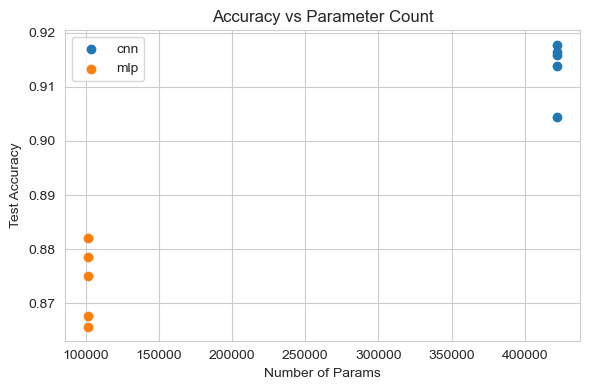

In [145]:
plt.figure(figsize=(6, 4))

for arch in clean_df["arch"].unique():
    subset = clean_df[clean_df["arch"] == arch]
    plt.scatter(subset["num_params"], subset["test_accuracy"], label=arch)

plt.xlabel("Number of Params")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Parameter Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "accuracy_vs_params.png", dpi=150)

plt.show()
plt.close()

#### Accuracy vs Training Time

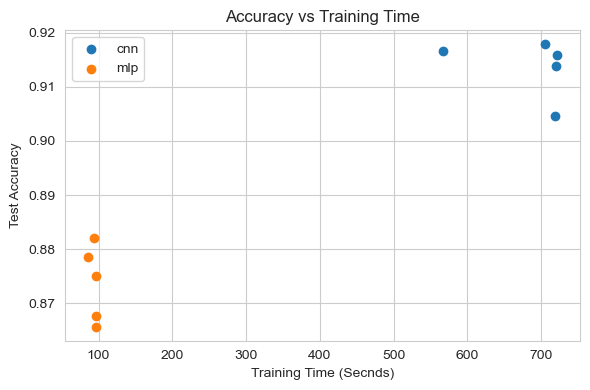

In [146]:
plt.figure(figsize=(6, 4))

for arch in clean_df["arch"].unique():
    subset = clean_df[clean_df["arch"] == arch]
    plt.scatter(subset["train_time_sec"], subset["test_accuracy"], label=arch)

plt.xlabel("Training Time (Secnds)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Training Time")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "accuracy_vs_time.png", dpi=150)

plt.show()
plt.close()

#### Generalisation Gap vs Depth

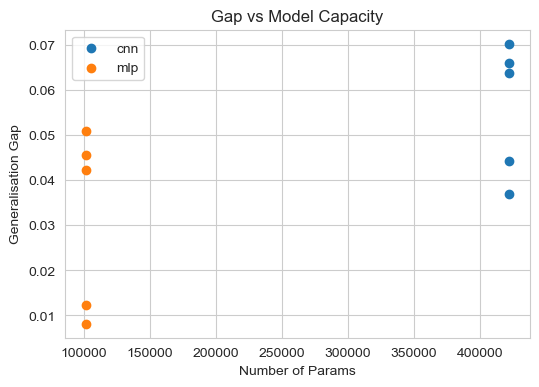

In [147]:
plt.figure(figsize=(6, 4))

for arch in clean_df["arch"].unique():
    subset = clean_df[clean_df["arch"] == arch]
    plt.scatter(subset["num_params"], subset["generalisation_gap"], label=arch)

plt.xlabel("Number of Params")
plt.ylabel("Generalisation Gap")
plt.title("Gap vs Model Capacity")
plt.legend()
plt.savefig(FIG_DIR / "gap_vs_capacity.png", dpi=150)

plt.show()
plt.close()

### Robustness Analysis

In [148]:
if robust_path.exists():
    robust_path = TABLE_DIR / "robustness_summary.csv"
    robust_df = pd.read_csv(robust_path)
else:
    print("Missing:", robust_path)

robust_df.head()

,model,condition,level,accuracy
0,mlp_baseline,clean,0.00,0.8750
1,mlp_dropout,clean,0.00,0.8820
2,cnn_baseline,clean,0.00,0.9138
3,cnn_dropout,clean,0.00,0.9178
4,mlp_baseline,gaussian_noise,0.05,0.8586


In [149]:
def plot_robustness(robust_df, condition, out_name):
    # Focus on a single corruption type
    sub = robust_df[robust_df["condition"] == condition].copy()
    if sub.empty:
        print("No rows for condition:", condition)
        return

    plt.figure(figsize=(6,4))
    for model in sorted(sub["model"].unique()):
        # Sort by severity
        m = sub[sub["model"] == model].sort_values("level")
        plt.plot(m["level"], m["accuracy"], marker="o", label=model)

    plt.xlabel("Severity")
    plt.ylabel("Accuracy")
    plt.title(f"Robustness: {condition}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / out_name, dpi=150)
    plt.show()

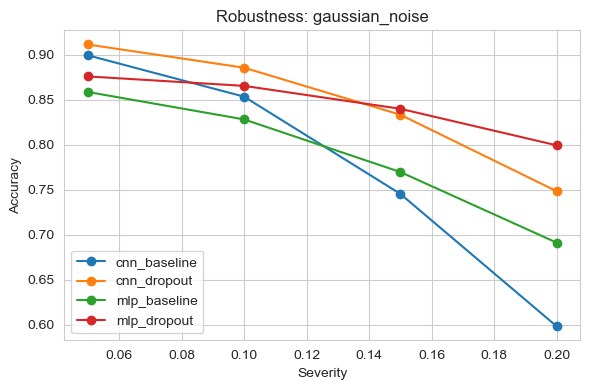

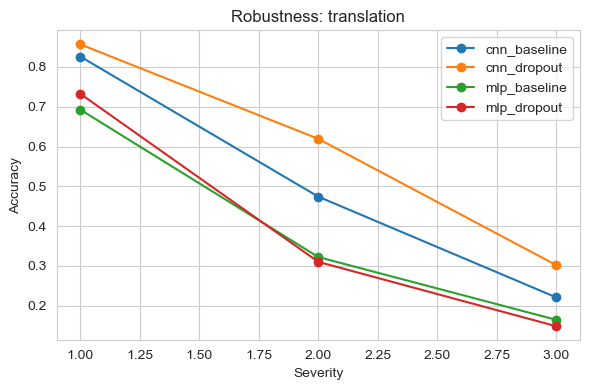

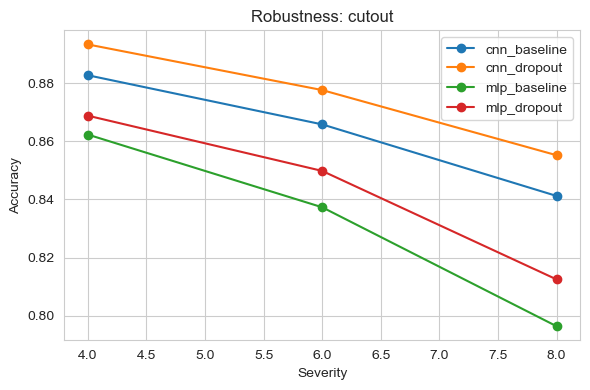

In [150]:
# Only attempt plotting if robustness results file is available
if robust_path.exists():
    for cond, fname in [
        ("gaussian_noise", "robustness_noise.png"),
        ("translation", "robustness_translation.png"),
        ("cutout", "robustness_cutout.png"),
    ]:
        plot_robustness(robust_df, cond, fname)

In [151]:
if robust_path.exists():
    # Extract clean baseline accuracy for each model
    clean_acc = (robust_df[robust_df["condition"] == "clean"][["model","accuracy"]]
                 .rename(columns={"accuracy":"clean_accuracy"}))
    # Attach clean accuracy to every robustness row
    merged = robust_df.merge(clean_acc, on="model", how="left")
    merged["accuracy_drop"] = merged["clean_accuracy"] - merged["accuracy"]

    # Exclude clean rows to focus only on corrupted inputs
    drop_df = merged[merged["condition"] != "clean"].copy()
    drop_df.to_csv(TABLE_DIR / "robustness_accuracy_drop.csv", index=False)

    # Show worst drops (largest accuracy drop)
    drop_df.sort_values("accuracy_drop", ascending=False).head(15)